# SIPARTA

### Bahan Kimia yang Dianalisis
| No | Bahan | Rumus Kimia |
|----|-------|-------------|
| 1 | Pemutih (Bleach) | NaClO |
| 2 | Amonia | NH₃ |
| 3 | Cuka (Asam Asetat) | CH₃COOH |
| 4 | Sabun Cuci Piring | Surfaktan |
| 5 | Pembersih Lantai (HCl) | HCl |
| 6 | Air | H₂O |

### Gas Beracun yang Terdeteksi
| Gas | Rumus | Sumber Reaksi |
|-----|-------|---------------|
| Kloramin | NH₂Cl | Pemutih + Amonia |
| Gas Klorin | Cl₂ | Pemutih + Cuka / Pemutih + HCl |
| Hidrogen Klorida | HCl (gas) | Pemutih + Asam kuat |

### Tingkat Risiko (Label Target)
- 0 = Aman - Tidak menghasilkan gas beracun
- 1 = Sedang - Potensi iritasi ringan
- 2 = Tinggi - Menghasilkan gas beracun berbahaya

---


---
## 1. Import Library

In [ ]:
# Library utama
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Cek versi & GPU
print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"GPU tersedia       : {tf.config.list_physical_devices('GPU')}")

# Reprodusibilitas
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
GPU tersedia       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2. Dataset Gas Beracun Rumah Tangga

Fitur input:
- `bahan_1` dan `bahan_2`: ID bahan kimia yang dicampur
- `pH_bahan_1`, `pH_bahan_2`: Tingkat pH masing-masing bahan
- `konsentrasi_1`, `konsentrasi_2`: Konsentrasi larutan (%)
- `suhu_ruangan`: Suhu lingkungan (°C)
- `ventilasi`: Skor ventilasi ruangan (0–1)
- `volume_campuran_ml`: Volume total campuran (ml)

Label target: `tingkat_risiko` (0=Aman, 1=Sedang, 2=Tinggi)

In [ ]:
# ============================================================
# Definisi bahan kimia rumah tangga
# ============================================================
BAHAN_KIMIA = {
    0: {'nama': 'Pemutih (NaClO)',       'pH': 12.5, 'konsentrasi_default': 5.0},
    1: {'nama': 'Amonia (NH3)',           'pH': 11.5, 'konsentrasi_default': 10.0},
    2: {'nama': 'Cuka (CH3COOH)',         'pH': 2.5,  'konsentrasi_default': 5.0},
    3: {'nama': 'Sabun Cuci Piring',      'pH': 7.0,  'konsentrasi_default': 15.0},
    4: {'nama': 'Pembersih Lantai (HCl)', 'pH': 1.0,  'konsentrasi_default': 10.0},
    5: {'nama': 'Air (H2O)',              'pH': 7.0,  'konsentrasi_default': 100.0},
}

# ============================================================
# Aturan risiko pencampuran (berdasarkan kimia)
# ============================================================
# Key: tuple (min_id, max_id), Value: tingkat_risiko
RISIKO_CAMPURAN = {
    (0, 1): 2,  # Pemutih + Amonia   -> Gas Kloramin (TINGGI)
    (0, 2): 2,  # Pemutih + Cuka     -> Gas Klorin (TINGGI)
    (0, 4): 2,  # Pemutih + HCl      -> Gas Klorin (TINGGI)
    (1, 2): 1,  # Amonia + Cuka      -> Amonium Asetat (SEDANG - iritasi)
    (1, 4): 1,  # Amonia + HCl       -> Amonium Klorida asap (SEDANG)
    (2, 4): 1,  # Cuka + HCl         -> Campuran asam (SEDANG)
    (2, 3): 1,  # Cuka + Sabun       -> Netralkan surfaktan (SEDANG)
    (0, 3): 1,  # Pemutih + Sabun    -> Potensi gas klorin ringan (SEDANG)
    (0, 5): 0,  # Pemutih + Air      -> Encer (AMAN)
    (1, 5): 0,  # Amonia + Air       -> Encer (AMAN)
    (2, 5): 0,  # Cuka + Air         -> Encer (AMAN)
    (3, 5): 0,  # Sabun + Air        -> Normal (AMAN)
    (4, 5): 0,  # HCl + Air          -> Encer (AMAN)
    (3, 4): 0,  # Sabun + HCl        -> Umumnya aman (AMAN)
    (1, 3): 0,  # Amonia + Sabun     -> Umumnya aman (AMAN)
}

GAS_BERACUN = {
    (0, 1): 'Kloramin (NH2Cl)',
    (0, 2): 'Gas Klorin (Cl2)',
    (0, 4): 'Gas Klorin (Cl2)',
    (1, 2): 'Uap Amonium Asetat',
    (1, 4): 'Asap Amonium Klorida',
    (2, 4): 'Uap Asam',
    (2, 3): 'Tidak ada gas berbahaya',
    (0, 3): 'Gas Klorin ringan',
}

print("\u2705 Definisi bahan dan aturan risiko siap")
print(f"   Jumlah bahan      : {len(BAHAN_KIMIA)}")
print(f"   Jumlah kombinasi  : {len(RISIKO_CAMPURAN)}")

✅ Definisi bahan dan aturan risiko siap
   Jumlah bahan      : 6
   Jumlah kombinasi  : 15


In [ ]:
# ============================================================
# Generate dataset sintetis
# ============================================================
def generate_dataset(n_samples=3000, seed=42):
    """
    Membuat dataset sintetis pencampuran bahan kimia rumah tangga.
    Setiap sampel = satu skenario pencampuran dua bahan dengan variasi
    konsentrasi, suhu, ventilasi, dan volume.
    """
    rng = np.random.RandomState(seed)
    records = []

    kombinasi_list = list(RISIKO_CAMPURAN.keys())
    n_kombinasi = len(kombinasi_list)

    for i in range(n_samples):
        # Pilih kombinasi bahan secara acak
        idx = rng.randint(0, n_kombinasi)
        bahan_1, bahan_2 = kombinasi_list[idx]

        # Ambil properti bahan
        info_1 = BAHAN_KIMIA[bahan_1]
        info_2 = BAHAN_KIMIA[bahan_2]

        # Variasi konsentrasi (dengan noise)
        konsentrasi_1 = max(0.5, info_1['konsentrasi_default'] + rng.normal(0, 2))
        konsentrasi_2 = max(0.5, info_2['konsentrasi_default'] + rng.normal(0, 2))

        # pH (sedikit variasi)
        pH_1 = info_1['pH'] + rng.normal(0, 0.3)
        pH_2 = info_2['pH'] + rng.normal(0, 0.3)

        # Kondisi lingkungan
        suhu_ruangan = rng.uniform(20, 40)          # Celsius
        ventilasi = rng.uniform(0, 1)                # 0=tertutup, 1=terbuka
        volume_campuran = rng.uniform(50, 500)       # ml

        # Selisih pH (indikator reaksi asam-basa)
        delta_pH = abs(pH_1 - pH_2)

        # Risiko dasar dari aturan
        risiko_dasar = RISIKO_CAMPURAN[(bahan_1, bahan_2)]

        # Modifikasi risiko berdasarkan kondisi:
        # - Konsentrasi tinggi & volume besar bisa naikkan risiko
        # - Ventilasi baik bisa turunkan risiko
        # - Suhu tinggi mempercepat reaksi
        risiko_score = risiko_dasar

        # Faktor konsentrasi: konsentrasi tinggi -> risiko naik
        if konsentrasi_1 > info_1['konsentrasi_default'] * 1.3 and risiko_dasar > 0:
            risiko_score = min(2, risiko_score + rng.choice([0, 1], p=[0.7, 0.3]))

        # Faktor suhu: suhu > 35 bisa naikkan risiko
        if suhu_ruangan > 35 and risiko_dasar >= 1:
            risiko_score = min(2, risiko_score + rng.choice([0, 1], p=[0.6, 0.4]))

        # Faktor ventilasi: ventilasi bagus turunkan efek (tapi tetap beracun)
        if ventilasi > 0.8 and risiko_dasar == 1:
            risiko_score = max(0, risiko_score - rng.choice([0, 1], p=[0.6, 0.4]))

        # Noise kecil (5% kemungkinan salah label - real-world noise)
        if rng.random() < 0.03:
            risiko_score = rng.choice([0, 1, 2])

        records.append({
            'bahan_1': bahan_1,
            'bahan_2': bahan_2,
            'pH_bahan_1': round(pH_1, 2),
            'pH_bahan_2': round(pH_2, 2),
            'delta_pH': round(delta_pH, 2),
            'konsentrasi_1': round(konsentrasi_1, 2),
            'konsentrasi_2': round(konsentrasi_2, 2),
            'suhu_ruangan': round(suhu_ruangan, 2),
            'ventilasi': round(ventilasi, 4),
            'volume_campuran_ml': round(volume_campuran, 1),
            'tingkat_risiko': int(risiko_score),
        })

    return pd.DataFrame(records)


# Generate dataset
df = generate_dataset(n_samples=3000, seed=42)

print(f"\u2705 Dataset berhasil dibuat: {df.shape[0]} sampel, {df.shape[1]} kolom")
df.head(10)

✅ Dataset berhasil dibuat: 3000 sampel, 11 kolom


,bahan_1,bahan_2,pH_bahan_1,pH_bahan_2,delta_pH,konsentrasi_1,konsentrasi_2,suhu_ruangan,ventilasi,volume_campuran_ml,tingkat_risiko
0,2,3,2.64,7.41,4.77,3.90,16.03,28.92,0.1000,256.7,1
1,0,3,12.33,6.72,5.61,3.84,13.95,30.50,0.4319,181.1,1
2,1,5,11.06,7.45,3.61,9.50,99.67,39.66,0.4668,437.0,0
3,0,5,12.32,7.56,4.76,3.80,99.42,22.44,0.4952,65.5,0
4,1,2,11.09,2.39,8.69,11.13,3.59,31.35,0.0313,429.0,1
5,1,5,11.20,6.53,4.67,10.44,101.76,25.43,0.8287,210.5,0
6,3,5,6.44,6.59,0.15,13.09,97.90,25.87,0.0141,139.5,0
7,0,4,12.60,1.29,11.31,3.32,9.38,26.62,0.0636,189.9,2
8,0,4,11.89,1.32,10.57,1.85,11.28,39.43,0.8489,374.8,2
9,2,5,2.53,6.91,4.38,0.50,101.64,26.29,0.5086,458.4,0


In [ ]:
# ============================================================
# Tambahkan kolom nama bahan (untuk eksplorasi)
# ============================================================
df['nama_bahan_1'] = df['bahan_1'].map(lambda x: BAHAN_KIMIA[x]['nama'])
df['nama_bahan_2'] = df['bahan_2'].map(lambda x: BAHAN_KIMIA[x]['nama'])
df['campuran'] = df['nama_bahan_1'] + ' + ' + df['nama_bahan_2']
df['label_risiko'] = df['tingkat_risiko'].map({0: 'Aman', 1: 'Sedang', 2: 'Tinggi'})

print("\nContoh data dengan nama bahan:")
df[['campuran', 'pH_bahan_1', 'pH_bahan_2', 'delta_pH',
    'konsentrasi_1', 'suhu_ruangan', 'ventilasi', 'label_risiko']].head(10)


Contoh data dengan nama bahan:


,campuran,pH_bahan_1,pH_bahan_2,delta_pH,konsentrasi_1,suhu_ruangan,ventilasi,label_risiko
0,Cuka (CH3COOH) + Sabun Cuci Piring,2.64,7.41,4.77,3.90,28.92,0.1000,Sedang
1,Pemutih (NaClO) + Sabun Cuci Piring,12.33,6.72,5.61,3.84,30.50,0.4319,Sedang
2,Amonia (NH3) + Air (H2O),11.06,7.45,3.61,9.50,39.66,0.4668,Aman
3,Pemutih (NaClO) + Air (H2O),12.32,7.56,4.76,3.80,22.44,0.4952,Aman
4,Amonia (NH3) + Cuka (CH3COOH),11.09,2.39,8.69,11.13,31.35,0.0313,Sedang
5,Amonia (NH3) + Air (H2O),11.20,6.53,4.67,10.44,25.43,0.8287,Aman
6,Sabun Cuci Piring + Air (H2O),6.44,6.59,0.15,13.09,25.87,0.0141,Aman
7,Pemutih (NaClO) + Pembersih Lantai (HCl),12.60,1.29,11.31,3.32,26.62,0.0636,Tinggi
8,Pemutih (NaClO) + Pembersih Lantai (HCl),11.89,1.32,10.57,1.85,39.43,0.8489,Tinggi
9,Cuka (CH3COOH) + Air (H2O),2.53,6.91,4.38,0.50,26.29,0.5086,Aman


In [ ]:
# ============================================================
# Simpan dataset ke CSV (opsional - untuk digunakan kembali)
# ============================================================
df.to_csv('dataset_gas_beracun_siparta.csv', index=False)
print("\u2705 Dataset tersimpan: dataset_gas_beracun_siparta.csv")

✅ Dataset tersimpan: dataset_gas_beracun_siparta.csv


---
## 3. Eksplorasi Data (EDA)

In [ ]:
# ============================================================
# Informasi Dataset
# ============================================================
print("=" * 60)
print("INFORMASI DATASET SIPARTA")
print("=" * 60)
print(f"Jumlah sampel  : {df.shape[0]}")
print(f"Jumlah fitur   : {df.shape[1]}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"\nTipe data:")
print(df.dtypes)
print(f"\nStatistik deskriptif:")
df.describe()

INFORMASI DATASET SIPARTA
Jumlah sampel  : 3000
Jumlah fitur   : 15
Missing values : 0

Tipe data:
bahan_1                 int64
bahan_2                 int64
pH_bahan_1            float64
pH_bahan_2            float64
delta_pH              float64
konsentrasi_1         float64
konsentrasi_2         float64
suhu_ruangan          float64
ventilasi             float64
volume_campuran_ml    float64
tingkat_risiko          int64
nama_bahan_1           object
nama_bahan_2           object
campuran               object
label_risiko           object
dtype: object

Statistik deskriptif:


,bahan_1,bahan_2,pH_bahan_1,pH_bahan_2,delta_pH,konsentrasi_1,konsentrasi_2,suhu_ruangan,ventilasi,volume_campuran_ml,tingkat_risiko
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1.348667,3.674667,8.674290,5.104807,5.603513,8.021970,40.546250,29.958703,0.499374,279.758167,0.769333
std,1.252313,1.249004,4.366426,3.197731,3.317133,4.097818,42.386607,5.697311,0.290412,130.632134,0.820376
min,0.000000,1.000000,0.030000,0.090000,0.000000,0.500000,0.500000,20.000000,0.000200,50.800000,0.000000
25%,0.000000,3.000000,2.900000,1.400000,4.050000,4.800000,9.390000,25.050000,0.247375,167.500000,0.000000
50%,1.000000,4.000000,11.380000,6.720000,5.230000,7.320000,13.590000,29.935000,0.507300,282.400000,1.000000
75%,2.000000,5.000000,12.280000,7.120000,8.682500,10.752500,98.750000,34.835000,0.746125,394.500000,1.000000
max,4.000000,5.000000,13.320000,12.100000,12.670000,20.710000,105.710000,39.990000,0.999800,500.000000,2.000000


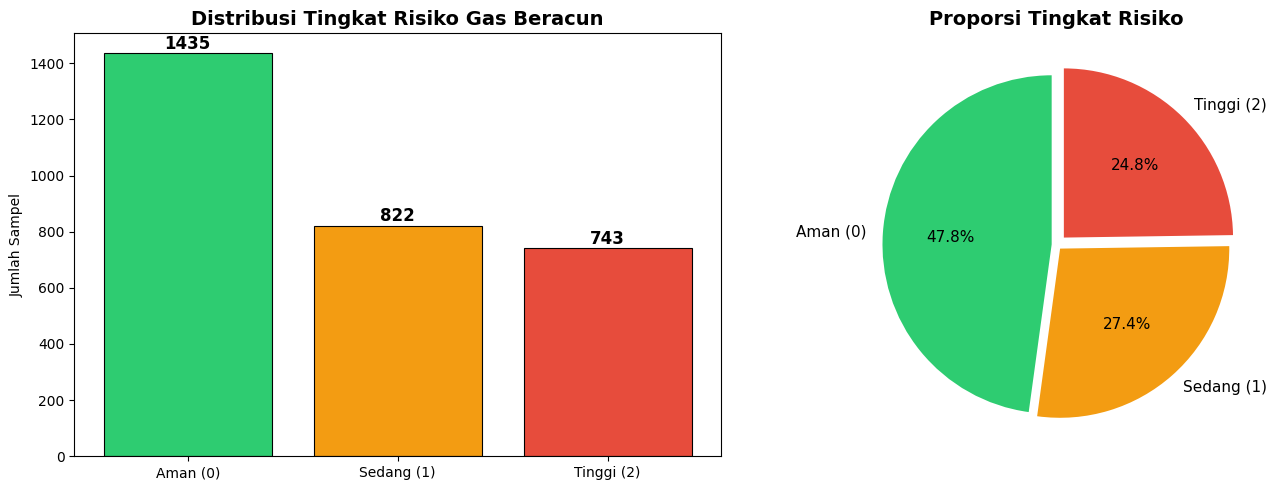

In [ ]:
# ============================================================
# Distribusi Tingkat Risiko
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
risk_counts = df['tingkat_risiko'].value_counts().sort_index()
risk_labels = ['Aman (0)', 'Sedang (1)', 'Tinggi (2)']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

bars = axes[0].bar(risk_labels, risk_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribusi Tingkat Risiko Gas Beracun', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for bar, val in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 15, str(val),
                ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(risk_counts.values, labels=risk_labels, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.03, 0.03, 0.06],
            textprops={'fontsize': 11})
axes[1].set_title('Proporsi Tingkat Risiko', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

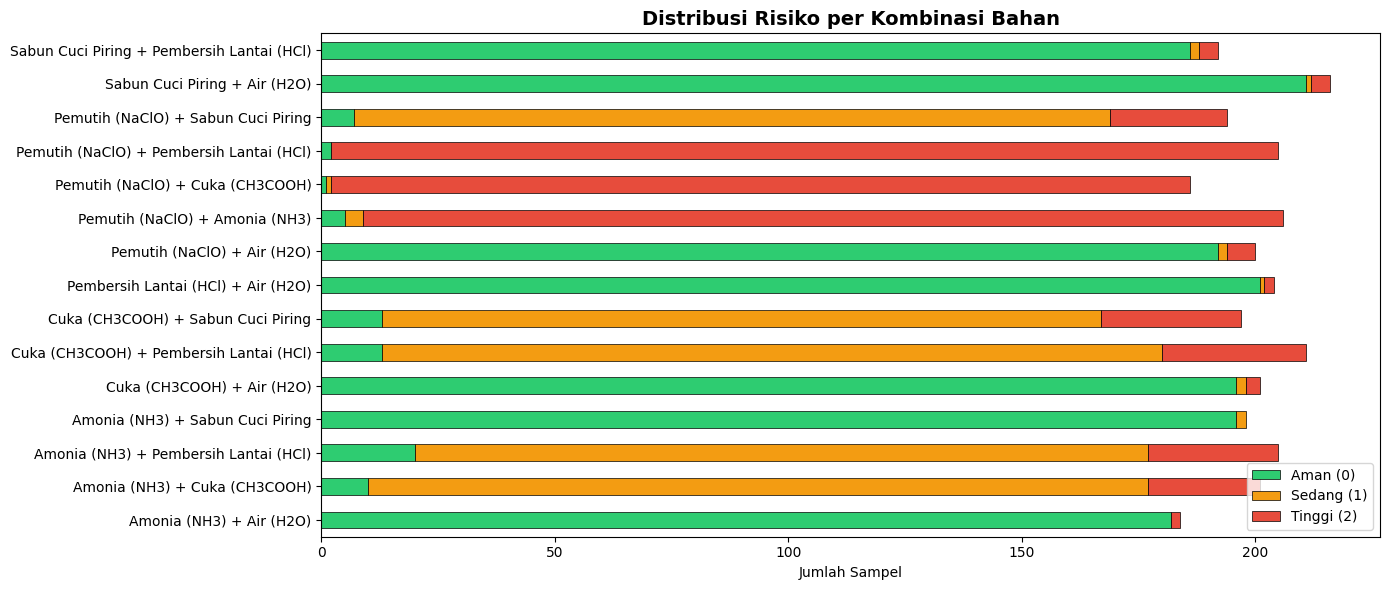

In [ ]:
# ============================================================
# Risiko per Kombinasi Bahan
# ============================================================
risk_by_mix = df.groupby(['campuran', 'tingkat_risiko']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
risk_by_mix.plot(kind='barh', stacked=True, color=colors, ax=ax, edgecolor='black', linewidth=0.5)
ax.set_title('Distribusi Risiko per Kombinasi Bahan', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Sampel')
ax.set_ylabel('')
ax.legend(['Aman (0)', 'Sedang (1)', 'Tinggi (2)'], loc='lower right')
plt.tight_layout()
plt.show()

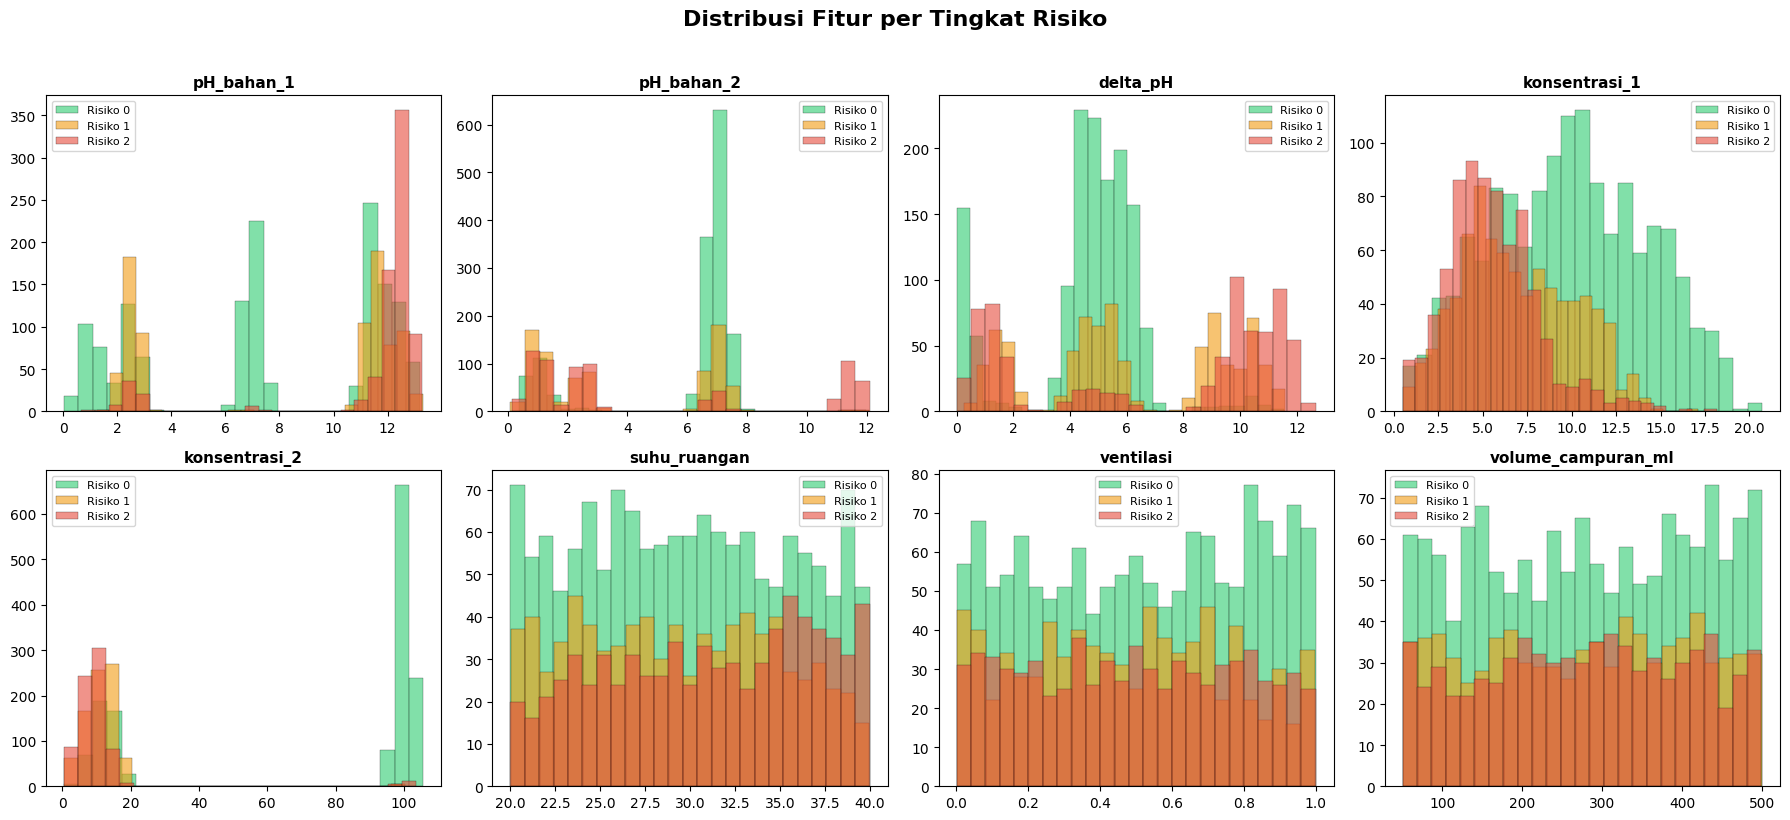

In [ ]:
# ============================================================
# Distribusi fitur numerik berdasarkan tingkat risiko
# ============================================================
fitur_numerik = ['pH_bahan_1', 'pH_bahan_2', 'delta_pH', 'konsentrasi_1',
                 'konsentrasi_2', 'suhu_ruangan', 'ventilasi', 'volume_campuran_ml']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(fitur_numerik):
    for risk_level, color in zip([0, 1, 2], colors):
        data = df[df['tingkat_risiko'] == risk_level][col]
        axes[i].hist(data, bins=25, alpha=0.6, color=color, label=f'Risiko {risk_level}',
                    edgecolor='black', linewidth=0.3)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur per Tingkat Risiko', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

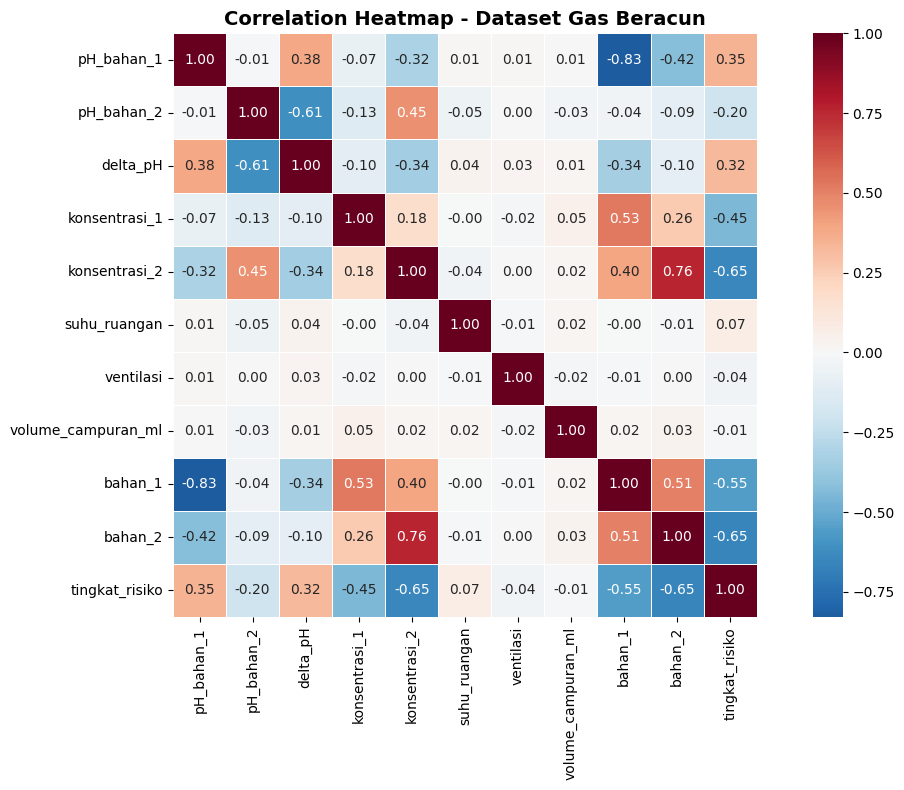

In [ ]:
# ============================================================
# Correlation Heatmap
# ============================================================
fitur_korelasi = fitur_numerik + ['bahan_1', 'bahan_2', 'tingkat_risiko']

plt.figure(figsize=(12, 8))
corr = df[fitur_korelasi].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Dataset Gas Beracun', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Preprocessing Data

In [ ]:
# ============================================================
# Pilih fitur dan target
# ============================================================
FEATURE_COLUMNS = [
    'bahan_1', 'bahan_2',
    'pH_bahan_1', 'pH_bahan_2', 'delta_pH',
    'konsentrasi_1', 'konsentrasi_2',
    'suhu_ruangan', 'ventilasi', 'volume_campuran_ml'
]
TARGET_COLUMN = 'tingkat_risiko'
NUM_CLASSES = 3  # Aman, Sedang, Tinggi

X = df[FEATURE_COLUMNS].values
y = df[TARGET_COLUMN].values

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"Kelas   : {np.unique(y)} (0=Aman, 1=Sedang, 2=Tinggi)")

Shape X : (3000, 10)
Shape y : (3000,)
Kelas   : [0 1 2] (0=Aman, 1=Sedang, 2=Tinggi)


In [ ]:
# ============================================================
# Split data: Train (70%), Validation (15%), Test (15%)
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Training set   : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set : {X_val.shape[0]} sampel ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set       : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set   : 2100 sampel (70.0%)
Validation set : 450 sampel (15.0%)
Test set       : 450 sampel (15.0%)


In [ ]:
# ============================================================
# Feature Scaling (StandardScaler)
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\u2705 Feature scaling selesai (StandardScaler)")
print(f"   Mean training (sesudah): {X_train_scaled.mean():.6f}")
print(f"   Std training (sesudah) : {X_train_scaled.std():.6f}")

✅ Feature scaling selesai (StandardScaler)
   Mean training (sesudah): -0.000000
   Std training (sesudah) : 1.000000


In [ ]:
# ============================================================
# One-Hot Encoding target (untuk multi-class classification)
# ============================================================
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat = to_categorical(y_val, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

print(f"\u2705 One-hot encoding selesai")
print(f"   y_train shape: {y_train_cat.shape}")
print(f"   Contoh: {y_train[:5]} -> ")
print(f"           {y_train_cat[:5]}")

✅ One-hot encoding selesai
   y_train shape: (2100, 3)
   Contoh: [0 0 0 2 0] -> 
           [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


---
## 5. Arsitektur ANN

Arsitektur model:
- Input Layer: 10 fitur
- Hidden Layer 1: 128 neuron + ReLU + BatchNorm + Dropout(0.3)
- Hidden Layer 2: 64 neuron + ReLU + BatchNorm + Dropout(0.3)
- Hidden Layer 3: 32 neuron + ReLU + BatchNorm + Dropout(0.2)
- Output Layer: 3 neuron + Softmax (multi-class: Aman/Sedang/Tinggi)

In [ ]:
# ============================================================
# Hyperparameter
# ============================================================
INPUT_DIM = X_train_scaled.shape[1]
LEARNING_RATE = 0.001
EPOCHS = 200
BATCH_SIZE = 32

print(f"Input dimension : {INPUT_DIM}")
print(f"Output classes  : {NUM_CLASSES}")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Epochs          : {EPOCHS}")
print(f"Batch size      : {BATCH_SIZE}")

Input dimension : 10
Output classes  : 3
Learning rate   : 0.001
Epochs          : 200
Batch size      : 32


In [ ]:
# ============================================================
# Bangun Model ANN
# ============================================================
def build_ann_model(input_dim, num_classes, learning_rate=0.001):
    """
    Membangun arsitektur ANN untuk klasifikasi tingkat risiko
    gas beracun dari reaksi kimia rumah tangga.

    Args:
        input_dim: Jumlah fitur input
        num_classes: Jumlah kelas output (3: Aman/Sedang/Tinggi)
        learning_rate: Learning rate untuk optimizer Adam

    Returns:
        model: Compiled Keras Sequential model
    """
    model = Sequential(name='SIPARTA_ANN')

    # Input + Hidden Layer 1
    model.add(Input(shape=(input_dim,)))
    model.add(Dense(128, activation='relu', kernel_initializer='he_normal', name='hidden_1'))
    model.add(BatchNormalization(name='bn_1'))
    model.add(Dropout(0.3, name='dropout_1'))

    # Hidden Layer 2
    model.add(Dense(64, activation='relu', kernel_initializer='he_normal', name='hidden_2'))
    model.add(BatchNormalization(name='bn_2'))
    model.add(Dropout(0.3, name='dropout_2'))

    # Hidden Layer 3
    model.add(Dense(32, activation='relu', kernel_initializer='he_normal', name='hidden_3'))
    model.add(BatchNormalization(name='bn_3'))
    model.add(Dropout(0.2, name='dropout_3'))

    # Output Layer (3 kelas: Aman, Sedang, Tinggi)
    model.add(Dense(num_classes, activation='softmax', name='output'))

    # Compile
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Buat model
model = build_ann_model(INPUT_DIM, NUM_CLASSES, LEARNING_RATE)

# Tampilkan arsitektur
model.summary()

Model: "SIPARTA_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,739 (49.76 KB)

 Trainable params: 12,291 (48.01 KB)

 Non-trainable params: 448 (1.75 KB)

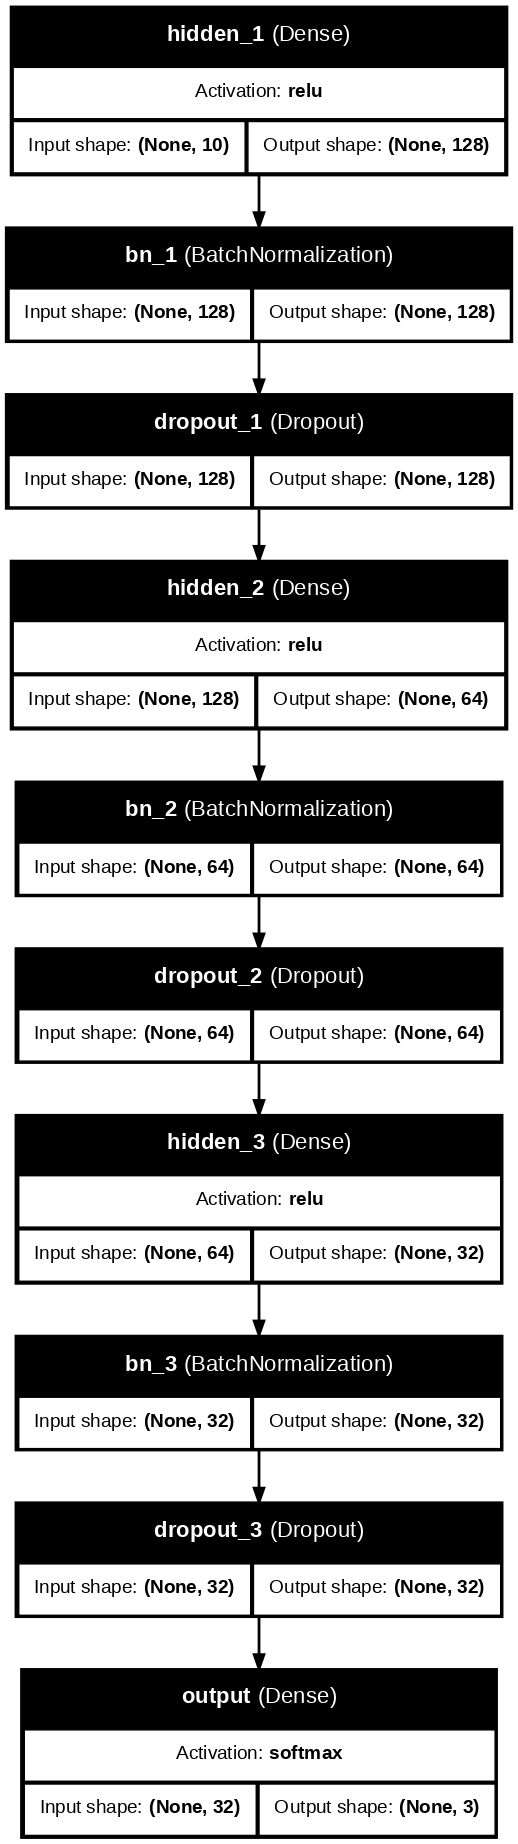

In [ ]:
# Visualisasi arsitektur model
tf.keras.utils.plot_model(
    model,
    to_file='siparta_ann_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    dpi=100
)

---
## 6. Training Model

In [ ]:
# ============================================================
# Definisi Callbacks
# ============================================================

# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

# Model Checkpoint
checkpoint = ModelCheckpoint(
    'siparta_best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks_list = [early_stopping, reduce_lr, checkpoint]
print("\u2705 Callbacks dikonfigurasi: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint")

✅ Callbacks dikonfigurasi: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [ ]:
# ============================================================
# Training
# ============================================================
print("\ud83d\ude80 Memulai training model SIPARTA ANN...\n")

history = model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)

print(f"\n\u2705 Training selesai!")
print(f"   Total epoch dijalankan: {len(history.history['loss'])}")

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 28-29: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/zmq/eventloop/zmqstream.py", line 551, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 120, in _handle_event
    event_f()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_s

54/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8999 - loss: 0.2931
Epoch 1: val_accuracy did not improve from 0.90667
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9148 - loss: 0.2605 - val_accuracy: 0.9044 - val_loss: 0.2918 - learning_rate: 2.5000e-04
Epoch 2/200
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9029 - loss: 0.2977
Epoch 2: val_accuracy did not improve from 0.90667
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9129 - loss: 0.2636 - val_accuracy: 0.9044 - val_loss: 0.2919 - learning_rate: 2.5000e-04
Epoch 3/200
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9026 - loss: 0.2916
Epoch 3: val_accuracy did not improve from 0.90667
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9100 - loss: 0.2648 - val_accuracy: 0.9044 - val_loss: 0.2931 - learning_rate: 2.5000e-04
Epoch 4/200
60/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9019 - loss: 0.2857
Epoch 4: val_accuracy did not improve from 0.90667
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/ste

---
## 7. Evaluasi Model

In [ ]:
# ============================================================
# Evaluasi pada Test Set
# ============================================================
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test_cat, verbose=0)

print("=" * 55)
print("  HASIL EVALUASI MODEL SIPARTA ANN - TEST SET")
print("=" * 55)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("=" * 55)

  HASIL EVALUASI MODEL SIPARTA ANN - TEST SET
  Test Loss     : 0.2540
  Test Accuracy : 0.9222 (92.22%)


In [ ]:
# ============================================================
# Prediksi & Classification Report
# ============================================================
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
target_names = ['Aman (0)', 'Sedang (1)', 'Tinggi (2)']
print(classification_report(y_test, y_pred, target_names=target_names))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Aman (0)       0.97      0.96      0.97       215
  Sedang (1)       0.82      0.98      0.89       124
  Tinggi (2)       0.98      0.77      0.86       111

    accuracy                           0.92       450
   macro avg       0.92      0.91      0.91       450
weighted avg       0.93      0.92      0.92       450



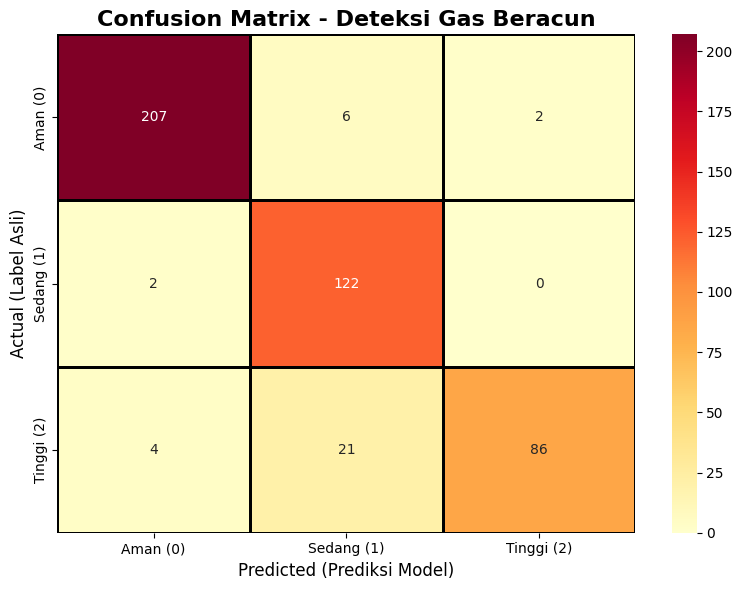


Akurasi per kelas:
  Aman (0): 0.9628 (207/215)
  Sedang (1): 0.9839 (122/124)
  Tinggi (2): 0.7748 (86/111)


In [ ]:
# ============================================================
# Confusion Matrix
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=target_names,
            yticklabels=target_names,
            linewidths=1, linecolor='black')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual (Label Asli)', fontsize=12)
plt.xlabel('Predicted (Prediksi Model)', fontsize=12)
plt.tight_layout()
plt.show()

# Hitung per-kelas accuracy
print("\nAkurasi per kelas:")
for i, name in enumerate(target_names):
    if cm[i].sum() > 0:
        acc = cm[i][i] / cm[i].sum()
        print(f"  {name}: {acc:.4f} ({cm[i][i]}/{cm[i].sum()})")

---
## 8. Visualisasi Hasil Training

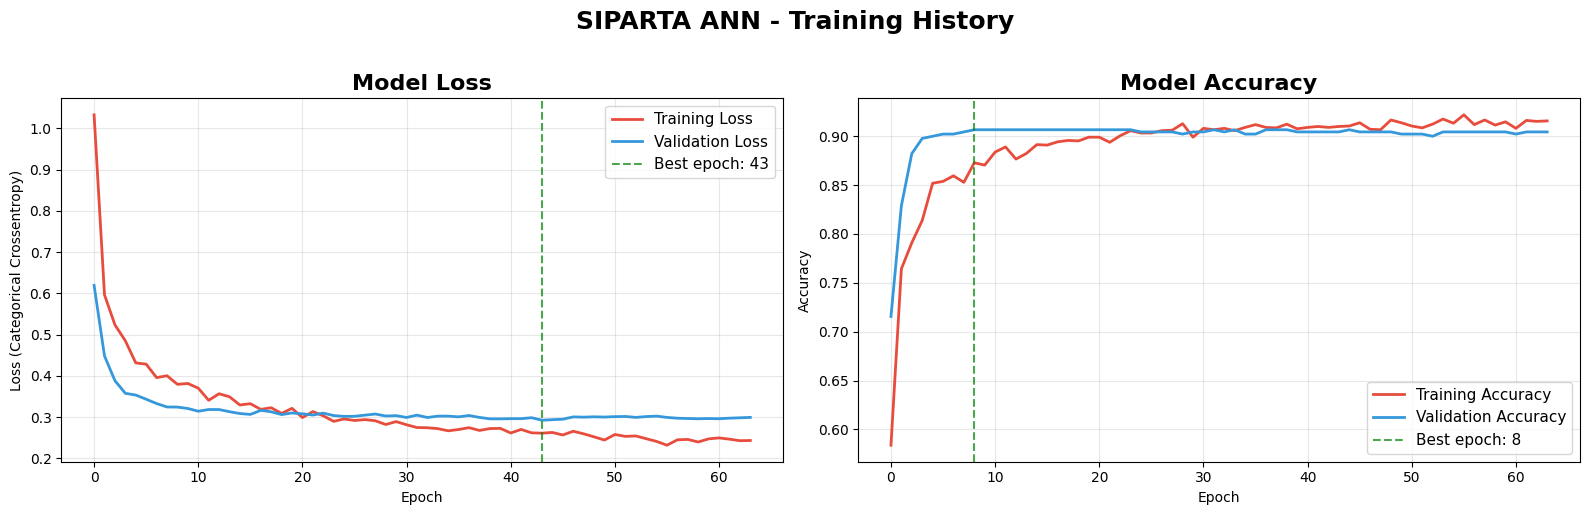

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/zmq/eventloop/zmqstream.py", line 551, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 120, in _handle_event
    event_f()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_s

In [ ]:
# ============================================================
# Plot Training History (Loss & Accuracy)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Loss ---
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='#e74c3c')
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='#3498db')
best_epoch_loss = np.argmin(history.history['val_loss'])
axes[0].axvline(x=best_epoch_loss, color='green', linestyle='--', alpha=0.7,
                label=f'Best epoch: {best_epoch_loss}')
axes[0].set_title('Model Loss', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Categorical Crossentropy)')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Accuracy ---
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='#e74c3c')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#3498db')
best_epoch_acc = np.argmax(history.history['val_accuracy'])
axes[1].axvline(x=best_epoch_acc, color='green', linestyle='--', alpha=0.7,
                label=f'Best epoch: {best_epoch_acc}')
axes[1].set_title('Model Accuracy', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('SIPARTA ANN - Training History', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n\ud83d\udcca Best val loss     : {min(history.history['val_loss']):.4f} (epoch {best_epoch_loss})")
print(f"\ud83d\udcca Best val accuracy : {max(history.history['val_accuracy']):.4f} (epoch {best_epoch_acc})")

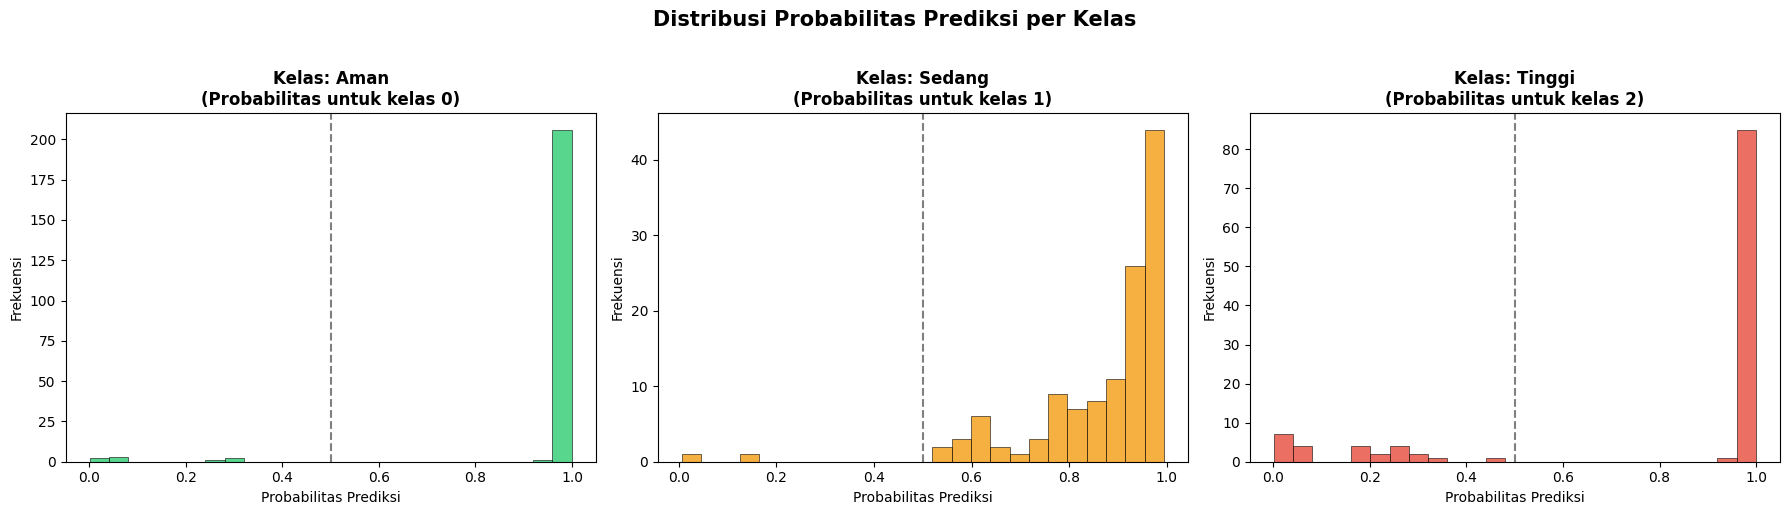

In [ ]:
# ============================================================
# Distribusi Probabilitas Prediksi per Kelas
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kelas_warna = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
kelas_nama = {0: 'Aman', 1: 'Sedang', 2: 'Tinggi'}

for cls in range(NUM_CLASSES):
    mask = y_test == cls
    probs = y_pred_proba[mask, cls]
    axes[cls].hist(probs, bins=25, color=kelas_warna[cls], edgecolor='black',
                   alpha=0.8, linewidth=0.5)
    axes[cls].set_title(f'Kelas: {kelas_nama[cls]}\n(Probabilitas untuk kelas {cls})',
                       fontsize=12, fontweight='bold')
    axes[cls].set_xlabel('Probabilitas Prediksi')
    axes[cls].set_ylabel('Frekuensi')
    axes[cls].axvline(x=0.5, color='black', linestyle='--', alpha=0.5)

plt.suptitle('Distribusi Probabilitas Prediksi per Kelas', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Prediksi Campuran Baru

Fungsi ini digunakan oleh aplikasi web SIPARTA untuk memprediksi tingkat risiko pencampuran dua bahan kimia rumah tangga.

In [ ]:
# ============================================================
# Fungsi Prediksi untuk SIPARTA
# ============================================================
def prediksi_risiko_campuran(model, scaler, bahan_1_id, bahan_2_id,
                             suhu=28.0, ventilasi=0.5, volume=200.0):
    """
    Memprediksi tingkat risiko pencampuran dua bahan kimia rumah tangga.

    Args:
        model: Trained Keras model
        scaler: Fitted StandardScaler
        bahan_1_id: ID bahan pertama (0-5)
        bahan_2_id: ID bahan kedua (0-5)
        suhu: Suhu ruangan (Celsius)
        ventilasi: Skor ventilasi (0-1)
        volume: Volume campuran (ml)

    Returns:
        dict: Hasil prediksi (risiko, probabilitas, gas, rekomendasi)
    """
    # Ambil info bahan
    info_1 = BAHAN_KIMIA[bahan_1_id]
    info_2 = BAHAN_KIMIA[bahan_2_id]

    # Siapkan fitur
    features = np.array([[
        bahan_1_id, bahan_2_id,
        info_1['pH'], info_2['pH'],
        abs(info_1['pH'] - info_2['pH']),
        info_1['konsentrasi_default'], info_2['konsentrasi_default'],
        suhu, ventilasi, volume
    ]])

    # Scaling & prediksi
    features_scaled = scaler.transform(features)
    proba = model.predict(features_scaled, verbose=0)[0]
    predicted_class = np.argmax(proba)

    # Label & rekomendasi
    label_map = {0: 'AMAN', 1: 'SEDANG', 2: 'TINGGI'}
    emoji_map = {0: '\u2705', 1: '\u26a0\ufe0f', 2: '\u2620\ufe0f'}
    rekomendasi_map = {
        0: 'Campuran umumnya aman. Tetap gunakan sesuai label produk.',
        1: 'Hati-hati! Potensi iritasi. Gunakan di ruangan berventilasi baik.',
        2: 'BAHAYA! Jangan mencampur! Dapat menghasilkan gas beracun. Gunakan secara terpisah.'
    }

    key = (min(bahan_1_id, bahan_2_id), max(bahan_1_id, bahan_2_id))
    gas = GAS_BERACUN.get(key, 'Tidak terdeteksi gas berbahaya')

    return {
        'bahan_1': info_1['nama'],
        'bahan_2': info_2['nama'],
        'tingkat_risiko': label_map[predicted_class],
        'emoji': emoji_map[predicted_class],
        'probabilitas': {label_map[i]: f'{proba[i]*100:.1f}%' for i in range(3)},
        'gas_beracun': gas,
        'rekomendasi': rekomendasi_map[predicted_class]
    }

In [ ]:
# ============================================================
# Contoh Prediksi: Semua Kombinasi
# ============================================================
print("=" * 70)
print("  SIPARTA - PREDIKSI RISIKO PENCAMPURAN BAHAN KIMIA RUMAH TANGGA")
print("=" * 70)

test_cases = [
    (0, 1, "Pemutih + Amonia"),
    (0, 2, "Pemutih + Cuka"),
    (0, 4, "Pemutih + Pembersih Lantai (HCl)"),
    (1, 2, "Amonia + Cuka"),
    (2, 3, "Cuka + Sabun Cuci Piring"),
    (3, 5, "Sabun Cuci Piring + Air"),
    (0, 5, "Pemutih + Air"),
]

for b1, b2, nama in test_cases:
    hasil = prediksi_risiko_campuran(model, scaler, b1, b2)
    print(f"\n{hasil['emoji']} {nama}")
    print(f"   Risiko      : {hasil['tingkat_risiko']}")
    print(f"   Probabilitas: {hasil['probabilitas']}")
    print(f"   Gas         : {hasil['gas_beracun']}")
    print(f"   Rekomendasi : {hasil['rekomendasi']}")

  SIPARTA - PREDIKSI RISIKO PENCAMPURAN BAHAN KIMIA RUMAH TANGGA

☠️ Pemutih + Amonia
   Risiko      : TINGGI
   Probabilitas: {'AMAN': '0.2%', 'SEDANG': '0.3%', 'TINGGI': '99.5%'}
   Gas         : Kloramin (NH2Cl)
   Rekomendasi : BAHAYA! Jangan mencampur! Dapat menghasilkan gas beracun. Gunakan secara terpisah.

☠️ Pemutih + Cuka
   Risiko      : TINGGI
   Probabilitas: {'AMAN': '0.1%', 'SEDANG': '0.0%', 'TINGGI': '99.9%'}
   Gas         : Gas Klorin (Cl2)
   Rekomendasi : BAHAYA! Jangan mencampur! Dapat menghasilkan gas beracun. Gunakan secara terpisah.

☠️ Pemutih + Pembersih Lantai (HCl)
   Risiko      : TINGGI
   Probabilitas: {'AMAN': '0.1%', 'SEDANG': '0.0%', 'TINGGI': '99.8%'}
   Gas         : Gas Klorin (Cl2)
   Rekomendasi : BAHAYA! Jangan mencampur! Dapat menghasilkan gas beracun. Gunakan secara terpisah.

⚠️ Amonia + Cuka
   Risiko      : SEDANG
   Probabilitas: {'AMAN': '1.0%', 'SEDANG': '97.7%', 'TINGGI': '1.3%'}
   Gas         : Uap Amonium Asetat
   Rekomendasi : Hati-

---
## 10. Simpan & Load Model

In [ ]:
# ============================================================
# Simpan model, scaler, dan training history
# ============================================================
import pickle
import json

# 1. Simpan model Keras
model.save('siparta_ann_model.keras')
print("\u2705 Model tersimpan: siparta_ann_model.keras")

# 2. Simpan scaler
with open('siparta_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\u2705 Scaler tersimpan: siparta_scaler.pkl")

# 3. Simpan training history
history_df = pd.DataFrame(history.history)
history_df.to_csv('siparta_training_history.csv', index=False)
print("\u2705 Training history tersimpan: siparta_training_history.csv")

# 4. Simpan konfigurasi bahan kimia (untuk web app)
config = {
    'bahan_kimia': {str(k): v for k, v in BAHAN_KIMIA.items()},
    'feature_columns': FEATURE_COLUMNS,
    'target_names': target_names,
    'num_classes': NUM_CLASSES
}
with open('siparta_config.json', 'w') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print("\u2705 Konfigurasi tersimpan: siparta_config.json")

✅ Model tersimpan: siparta_ann_model.keras
✅ Scaler tersimpan: siparta_scaler.pkl
✅ Training history tersimpan: siparta_training_history.csv
✅ Konfigurasi tersimpan: siparta_config.json


In [ ]:
# ============================================================
# Load & Verifikasi model
# ============================================================
loaded_model = tf.keras.models.load_model('siparta_ann_model.keras')

with open('siparta_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Verifikasi
verify_loss, verify_acc = loaded_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"\u2705 Model berhasil di-load")
print(f"   Test Accuracy (original) : {test_accuracy:.4f}")
print(f"   Test Accuracy (loaded)   : {verify_acc:.4f}")
print(f"   Match: {abs(verify_acc - test_accuracy) < 1e-6}")

✅ Model berhasil di-load
   Test Accuracy (original) : 0.9222
   Test Accuracy (loaded)   : 0.9222
   Match: True


In [ ]:
# ============================================================
# Download file dari Colab (opsional)
# ============================================================
# Uncomment untuk download:

# from google.colab import files
# files.download('siparta_ann_model.keras')
# files.download('siparta_scaler.pkl')
# files.download('siparta_config.json')
# files.download('siparta_training_history.csv')
# files.download('dataset_gas_beracun_siparta.csv')

---
# ============================================================
# TFLITE CONVERSION (Pipeline Integrasi Edge AI)
# ============================================================
# Tahap krusial untuk perangkat Edge (Raspberry Pi 3 B+):
# Model `.keras` yang berat akan dikonversi menjadi format `.tflite`.
# Format ini dapat dieksekusi oleh `tflite-runtime` dengan memori sangat rendah.


In [ ]:
# ============================================================
# 1. Konversi Keras ke TensorFlow Lite
# ============================================================
import tensorflow as tf

# Gunakan converter bawaan TF
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model TFLite
with open('siparta_edge_model.tflite', 'wb') as f:
    f.write(tflite_model)
    
print("✅ Model sukses dikonversi menjadi: siparta_edge_model.tflite")


---
# ============================================================
# SIMULASI INTEGRASI main_rpi.py
# ============================================================
# Menguji simulasi alur `main_rpi.py` langsung di Notebook.
# Menjalankan model Edge (.tflite) dan melakukan triger HTTP ke Backend / Web3.


In [ ]:
# ============================================================
# 2. Simulasi Eksekusi tflite-runtime ala main_rpi.py
# ============================================================
import numpy as np

# A. Inisialisasi Interpreter TFLite (seperti di Raspberry Pi)
interpreter = tf.lite.Interpreter(model_path="siparta_edge_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def inferensi_rpi_tflite(features):
    """
    Fungsi replika dari run_inference() di main_rpi.py
    """
    # Lakukan scaling menggunakan scaler yang sudah kita fit (di RPi bisa pakai Matrix statis)
    features_scaled = scaler.transform([features]).astype(np.float32)
    
    # Set Tensor Input
    interpreter.set_tensor(input_details[0]['index'], features_scaled)
    
    # Jalankan Edge Inferensi
    interpreter.invoke()
    
    # Ambil Hasil
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_class = np.argmax(output_data)
    
    status_map = {0: "AMAN", 1: "WASPADA", 2: "BAHAYA"}
    return status_map[predicted_class]

# B. Testing dengan dummy payload (Asumsi Campuran Pemutih & HCl)
# Berdasarkan urutan fitur: [bahan_1, bahan_2, pH_1, pH_2, diff, kon_1, kon_2, suhu, ventilasi, vol]
dummy_sensor_payload = [0, 4, 12.0, 1.0, 11.0, 5.0, 20.0, 30.0, 0.2, 500.0]

status_terdeteksi = inferensi_rpi_tflite(dummy_sensor_payload)
print(f"📡 Data Telemetri masuk: {dummy_sensor_payload}")
print(f"🧠 Hasil Edge TFLite  : {status_terdeteksi}")

# C. Triger Hardware Aktuator & Komunikasi Eksternal
if status_terdeteksi == "BAHAYA":
    print("\n🚨 [HARDWARE TRIGGER] Menghidupkan LED Merah & Buzzer 5V...")
    print("📸 [CAMERA MODULE] RPi OV5647 mengambil foto bukti (danger_log_xxx.jpg)!")
    print("🌐 [WEB3 & BACKEND] Mengirim Multipart Data (JSON + Image) ke FastAPI /api/v1/incidents/report...")
